In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/randasrour/ustctfc2016/LICENSE
/kaggle/input/datasets/randasrour/ustctfc2016/README.md
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/Outlook.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/WorldOfWarcraft.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/BitTorrent.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/Skype.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/Gmail.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/Facetime.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/FTP.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/MySQL.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/SMB/SMB/SMB-2.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/SMB/SMB/SMB-1.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/Weibo/Weibo/Weibo-3.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/Weibo/Weibo/Weibo-4.pcap
/kaggle/input/datasets/randasrour/ustctfc2016/Benign/Weibo/W

This notebook presents a hybrid machine learning framework for detecting covert communication patterns within encrypted QUIC and HTTP/3 network traffic using statistical and behavioral traffic analysis techniques. The implementation integrates the full CICIDS2017 intrusion detection dataset, the USTC-TFC2016 encrypted traffic dataset, and a real QUIC network capture dataset to improve behavioral diversity and protocol relevance. Due to the limited availability of publicly labeled QUIC covert-channel datasets, simulated covert behavior was introduced by injecting controlled anomalies into selected traffic patterns to emulate covert communication activity within encrypted environments. The framework applies data preprocessing, feature normalization, dimensionality reduction using Principal Component Analysis (PCA), and machine learning classification using both Random Forest and Support Vector Machine (SVM) models for comparative evaluation. In addition, visualization techniques including histogram-based feature distribution analysis, scatter plot feature-space visualization, confusion matrix analysis, and model comparison metrics are used to evaluate detection performance and interpret traffic behavior patterns. The objective of this implementation is to demonstrate how observable statistical and behavioral characteristics can support covert communication detection in encrypted traffic environments without relying on payload inspection, thereby preserving privacy while improving network security monitoring capabilities.

CICIDS Loaded: (2214469, 79)
QUIC Path: /kaggle/input/datasets/adam357/quic-network-capture-data
USTC Path: /kaggle/input/datasets/randasrour/ustctfc2016

--- QUIC Normal Traffic ---
  [0] traffic_record_normal.pcap (113 MB)
    -> 30000 packets extracted
  [0] traffic_record_normal1.pcap (62 MB)
    -> 30000 packets extracted
  [0] traffic_record_normal2.pcap (90 MB)
    -> 30000 packets extracted
  [0] traffic_record_normal3.pcap (76 MB)
    -> 30000 packets extracted
--- QUIC GET_FLOOD (attack) ---
  [1] recording_1.pcap (383 MB)
    -> 30000 packets extracted
  [1] recording_10.pcap (13 MB)
    -> 17324 packets extracted
  [1] recording_11.pcap (105 MB)
    -> 30000 packets extracted
  [1] recording_12.pcap (13 MB)
    -> 17311 packets extracted
--- QUIC SCAN (attack) ---
  [1] SCAN2_HTTP3.pcap (49 MB)
    -> 30000 packets extracted
  [1] SCAN3_HTTP3.pcap (37 MB)
    -> 30000 packets extracted

--- USTC Benign ---
  [0] BitTorrent.pcap (7 MB)
    -> 15000 packets extracted
  [0] FT

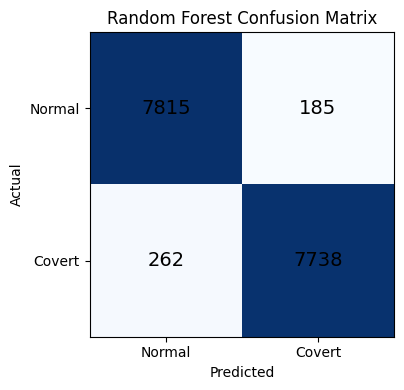

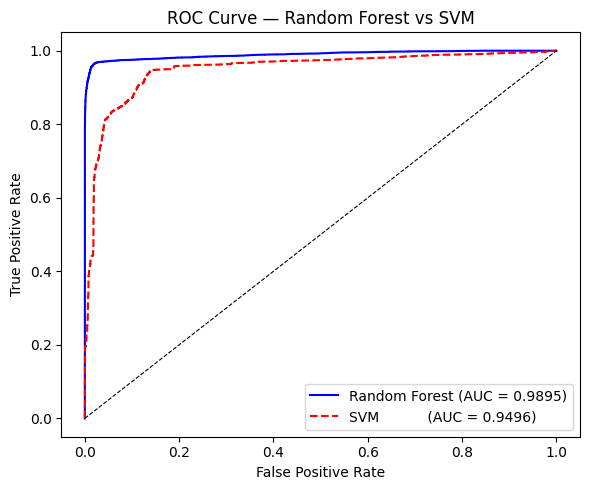

RF  AUC: 0.9895
SVM AUC: 0.9496


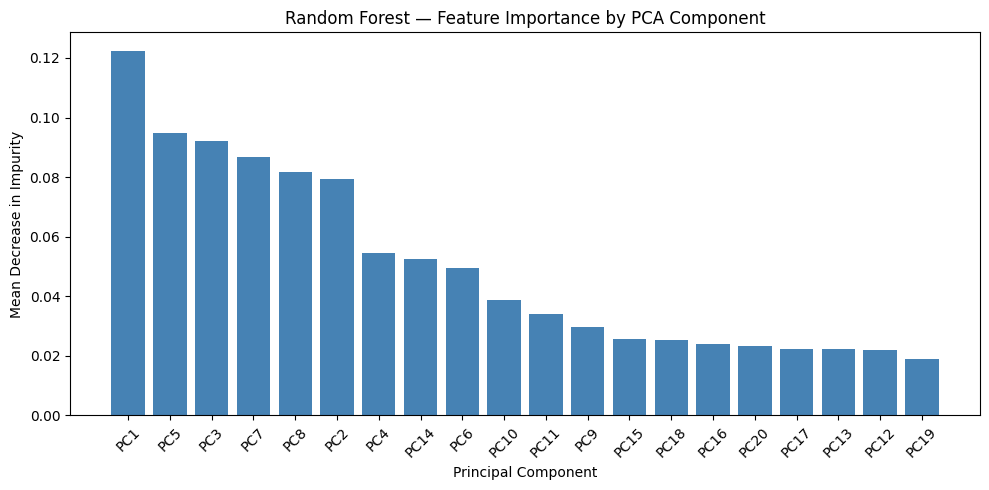


Feature importance ranking:
  Rank  1: PC1 — 0.1225
  Rank  2: PC5 — 0.0949
  Rank  3: PC3 — 0.0920
  Rank  4: PC7 — 0.0868
  Rank  5: PC8 — 0.0817
  Rank  6: PC2 — 0.0794
  Rank  7: PC4 — 0.0547
  Rank  8: PC14 — 0.0524
  Rank  9: PC6 — 0.0494
  Rank 10: PC10 — 0.0387
  Rank 11: PC11 — 0.0342
  Rank 12: PC9 — 0.0296
  Rank 13: PC15 — 0.0255
  Rank 14: PC18 — 0.0254
  Rank 15: PC16 — 0.0241
  Rank 16: PC20 — 0.0233
  Rank 17: PC17 — 0.0223
  Rank 18: PC13 — 0.0223
  Rank 19: PC12 — 0.0220
  Rank 20: PC19 — 0.0188


/tmp/ipykernel_16/1222109439.py:486: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


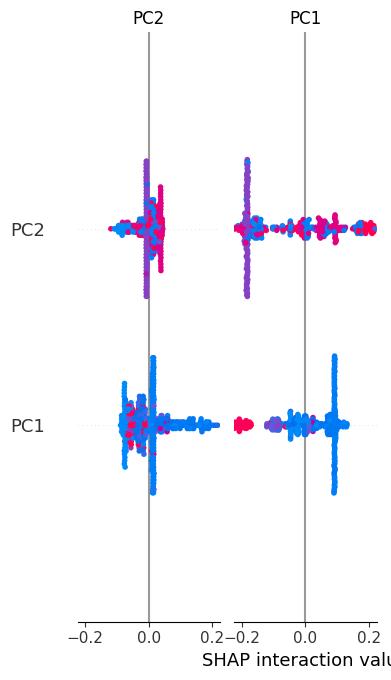

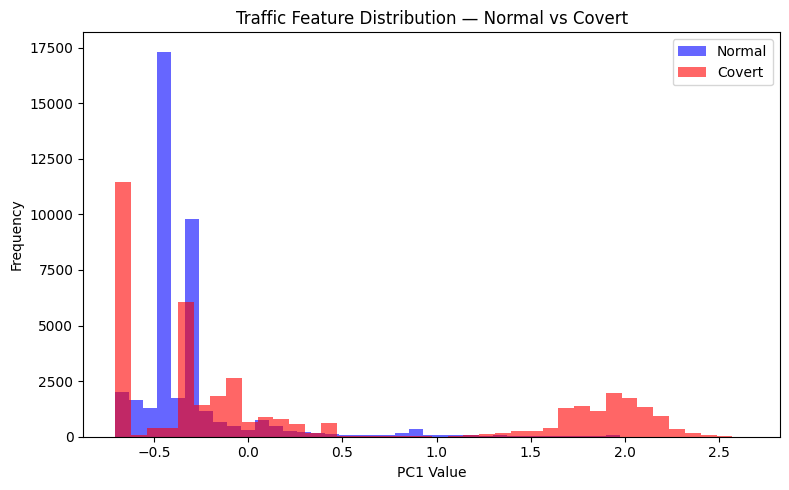

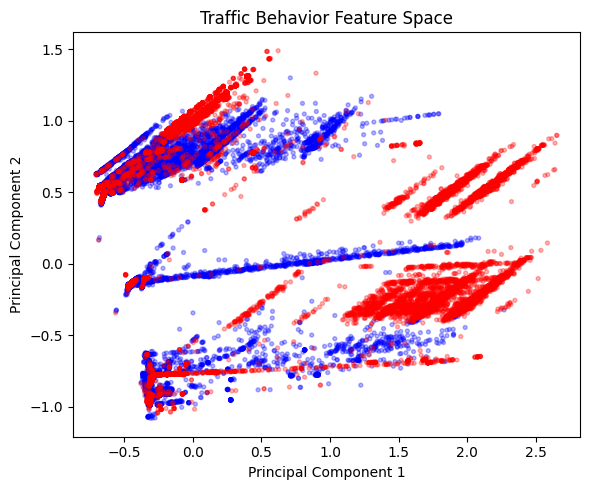

In [2]:
# =========================================================
# ENCRYPTED QUIC COVERT DETECTION
# FINAL HYBRID RESEARCH PIPELINE
#
# DATASETS:
# 1. CICIDS2017 FULL DATASET
# 2. USTC-TFC2016 (Benign + Malware pcap)
# 3. REAL QUIC NETWORK CAPTURE DATASET (normal + attack pcap)
# =========================================================

import subprocess
subprocess.run(["pip", "install", "shap", "-q"], check=True)

import pandas as pd
import numpy as np
import os
import struct
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    roc_curve, auc
)

import kagglehub

# =========================================================
# 1. LOAD CICIDS2017
# =========================================================

cicids_path = kagglehub.dataset_download("sweety18/cicids2017-full-dataset")
cicids_files = [f for f in os.listdir(cicids_path) if f.endswith(".csv")]
cicids = pd.read_csv(os.path.join(cicids_path, cicids_files[0]), low_memory=False)
cicids.columns = cicids.columns.str.strip()
print("CICIDS Loaded:", cicids.shape)

label_col = None
for col in ["Label", "label", "Class", "Attack Type"]:
    if col in cicids.columns:
        label_col = col
        break
if label_col is None:
    raise ValueError("Label column not found")

labels = cicids[label_col].astype(str)
y = labels.apply(lambda x: 0 if x.lower() in ["benign", "normal"] else 1)
X = cicids.drop(columns=[label_col])

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X = X.select_dtypes(include=[np.number])

# =========================================================
# 2. LOAD QUIC AND USTC PATHS
# =========================================================

quic_path = kagglehub.dataset_download("adam357/quic-network-capture-data")
ustc_path = kagglehub.dataset_download("randasrour/ustctfc2016")
print("QUIC Path:", quic_path)
print("USTC Path:", ustc_path)

# =========================================================
# 3. PURE PYTHON PCAP PARSER (no external dependencies)
# =========================================================

def parse_pcap(filepath, max_packets=30000):
    packets = []
    try:
        with open(filepath, "rb") as f:
            magic = f.read(4)
            if len(magic) < 4:
                return packets
            if magic == b'\xd4\xc3\xb2\xa1':
                endian = '<'
            elif magic == b'\xa1\xb2\xc3\xd4':
                endian = '>'
            else:
                return packets
            header = f.read(20)
            if len(header) < 20:
                return packets
            network_type = struct.unpack(endian + 'I', header[16:20])[0]
            count = 0
            while count < max_packets:
                rec = f.read(16)
                if len(rec) < 16:
                    break
                ts_sec, ts_usec, incl_len, orig_len = struct.unpack(
                    endian + 'IIII', rec
                )
                timestamp = ts_sec + ts_usec / 1e6
                data = f.read(incl_len)
                if len(data) < incl_len:
                    break
                src_ip = None
                try:
                    if network_type == 1:
                        if len(data) >= 34:
                            eth_type = struct.unpack('!H', data[12:14])[0]
                            if eth_type == 0x0800:
                                src_ip = '.'.join(str(b) for b in data[26:30])
                    elif network_type == 101:
                        if len(data) >= 20:
                            src_ip = '.'.join(str(b) for b in data[12:16])
                except Exception:
                    pass
                if src_ip:
                    packets.append((timestamp, src_ip, orig_len))
                count += 1
    except Exception as e:
        print(f"  Parse error {os.path.basename(filepath)}: {e}")
    return packets


def extract_features_from_pcap(filepath, label, max_packets=30000):
    packets = parse_pcap(filepath, max_packets)
    if len(packets) < 10:
        return None
    first_src  = packets[0][1]
    first_time = packets[0][0]
    times, sizes, fwd_sizes, bwd_sizes = [], [], [], []
    for ts, src, size in packets:
        t = ts - first_time
        times.append(t)
        sizes.append(size)
        if src == first_src:
            fwd_sizes.append(size)
        else:
            bwd_sizes.append(size)
    sizes    = np.array(sizes, dtype=float)
    times    = np.array(times, dtype=float)
    iats     = np.diff(times) if len(times) > 1 else np.array([0.0])
    fwd      = np.array(fwd_sizes, dtype=float) if fwd_sizes else np.array([0.0])
    bwd      = np.array(bwd_sizes, dtype=float) if bwd_sizes else np.array([0.0])
    duration = times[-1] - times[0] if len(times) > 1 else 0.0
    return {
        "pkt_count":       float(len(sizes)),
        "flow_duration":   duration,
        "pkt_size_mean":   float(sizes.mean()),
        "pkt_size_std":    float(sizes.std()),
        "pkt_size_min":    float(sizes.min()),
        "pkt_size_max":    float(sizes.max()),
        "pkt_size_median": float(np.median(sizes)),
        "pkt_size_q25":    float(np.percentile(sizes, 25)),
        "pkt_size_q75":    float(np.percentile(sizes, 75)),
        "iat_mean":        float(iats.mean()),
        "iat_std":         float(iats.std()),
        "iat_min":         float(iats.min()),
        "iat_max":         float(iats.max()),
        "iat_median":      float(np.median(iats)),
        "fwd_pkt_count":   float(len(fwd)),
        "bwd_pkt_count":   float(len(bwd)),
        "fwd_size_mean":   float(fwd.mean()),
        "bwd_size_mean":   float(bwd.mean()),
        "fwd_size_total":  float(fwd.sum()),
        "bwd_size_total":  float(bwd.sum()),
        "fwd_bwd_ratio":   float(len(fwd)) / (float(len(bwd)) + 1),
        "bytes_per_sec":   float(sizes.sum()) / (duration + 1e-6),
        "pkts_per_sec":    float(len(sizes)) / (duration + 1e-6),
        "burst_mean":      float(np.mean(sizes[::10])),
        "size_variance":   float(np.var(sizes)),
        "label":           label
    }


def process_folder(folder_path, label, max_files=4):
    rows = []
    count = 0
    for root, dirs, files in os.walk(folder_path):
        for f in sorted(files):
            if not f.endswith(".pcap") or count >= max_files:
                continue
            fpath = os.path.join(root, f)
            size_mb = os.path.getsize(fpath) // (1024 * 1024)
            print(f"  [{label}] {f} ({size_mb} MB)")
            row = extract_features_from_pcap(fpath, label)
            if row is not None:
                rows.append(row)
                print(f"    -> {int(row['pkt_count'])} packets extracted")
            else:
                print(f"    -> skipped (too few IP packets)")
            count += 1
    return rows

# =========================================================
# 4. EXTRACT FROM QUIC DATASET
# =========================================================

print("\n--- QUIC Normal Traffic ---")
extra_rows = process_folder(
    os.path.join(quic_path, "normal_traffic_7/traffic_normal"),
    label=0, max_files=4
)

print("--- QUIC GET_FLOOD (attack) ---")
extra_rows += process_folder(
    os.path.join(quic_path, "traffic_recording/traffic_recording/GET_FLOOD_PCAP"),
    label=1, max_files=4
)

print("--- QUIC SCAN (attack) ---")
extra_rows += process_folder(
    os.path.join(quic_path, "traffic_recording/traffic_recording/SCAN_PCAP"),
    label=1, max_files=2
)

# =========================================================
# 5. EXTRACT FROM USTC DATASET
# =========================================================

print("\n--- USTC Benign ---")
extra_rows += process_folder(
    os.path.join(ustc_path, "Benign"),
    label=0, max_files=5
)

print("--- USTC Malware ---")
extra_rows += process_folder(
    os.path.join(ustc_path, "Malware"),
    label=1, max_files=5
)

df_extra = pd.DataFrame(extra_rows) if extra_rows else pd.DataFrame()
print(f"\nTotal pcap flow records extracted: {len(df_extra)}")
if not df_extra.empty:
    print("Label distribution:\n", df_extra["label"].value_counts())


# =========================================================
# 6. SIMULATED COVERT BEHAVIOR ON CICIDS
# =========================================================

X_simulated = X.copy()
np.random.seed(42)
indices = np.random.choice(X_simulated.index, 30000, replace=False)
for col in X_simulated.columns[:5]:
    X_simulated.loc[indices, col] *= np.random.uniform(1.5, 3.0)
y_sim = y.copy()
y_sim.loc[indices] = 1

# =========================================================
# 7. MERGE CICIDS + PCAP FEATURES
# =========================================================

if not df_extra.empty:
    extra_y = df_extra["label"].values
    extra_X = df_extra.drop(columns=["label"])
    extra_aligned = pd.DataFrame(
        np.zeros((len(df_extra), X_simulated.shape[1])),
        columns=X_simulated.columns
    )
    for i, col in enumerate(extra_X.columns):
        if i < X_simulated.shape[1]:
            extra_aligned.iloc[:, i] = extra_X.iloc[:, i].values
    X_all = pd.concat([X_simulated, extra_aligned], ignore_index=True)
    y_all = np.concatenate([y_sim.values, extra_y])
    print("Combined dataset shape:", X_all.shape)
    print(f"Note: {len(df_extra)} pcap flow records merged into {len(X_simulated):,} CICIDS rows ({100*len(df_extra)/len(X_all):.3f}% of total)")
else:
    X_all = X_simulated
    y_all = y_sim.values

print("\nCombined dataset shape:", X_all.shape)

# =========================================================
# 8. STRATIFIED SAMPLE FOR CLASS BALANCE
# =========================================================

df_temp = pd.DataFrame(X_all.values, columns=X_simulated.columns)
df_temp["label"] = y_all
n_per_class = min(40000, df_temp.groupby("label").size().min())
df_sample = df_temp.groupby("label").sample(n=n_per_class, random_state=42)
X_sampled = df_sample.drop(columns=["label"]).values
y_sampled = df_sample["label"].values
print("Sampled dataset shape:", X_sampled.shape)
print("Label counts:", np.unique(y_sampled, return_counts=True))

# =========================================================
# 9. TRAIN/TEST SPLIT FIRST (fixes data leakage)
# =========================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_sampled, y_sampled,
    test_size=0.2,
    stratify=y_sampled,
    random_state=42
)

# =========================================================
# 10. FIT SCALER ON TRAIN ONLY
# =========================================================

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# =========================================================
# 11. FIT PCA ON TRAIN ONLY
# =========================================================

pca = PCA(n_components=20)
X_train_final = pca.fit_transform(X_train_scaled)
X_test_final  = pca.transform(X_test_scaled)

print("Train shape:", X_train_final.shape)
print("Test shape: ", X_test_final.shape)
print(f"PCA explained variance (20 components): {pca.explained_variance_ratio_.sum():.4f}")

# =========================================================
# 12. RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_final, y_train)
rf_pred = rf_model.predict(X_test_final)

print("\n========== RANDOM FOREST ==========")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

# =========================================================
# 13. SVM BASELINE (linear kernel, full test set)
# =========================================================

svm_model = CalibratedClassifierCV(
    LinearSVC(max_iter=2000, random_state=42)
)
svm_model.fit(X_train_final, y_train)
svm_pred = svm_model.predict(X_test_final)

print("\n=============== SVM ===============")
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))

# =========================================================
# 14. 5-FOLD CROSS-VALIDATION
# =========================================================

X_all_scaled = scaler.transform(X_sampled)
X_all_pca    = pca.transform(X_all_scaled)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = cross_validate(
    RandomForestClassifier(
        n_estimators=100, max_depth=12,
        n_jobs=-1, random_state=42
    ),
    X_all_pca, y_sampled,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("\n===== 5-FOLD CROSS-VALIDATION (RF) =====")
for fold in range(5):
    print(f"Fold {fold+1}: Accuracy={rf_cv['test_accuracy'][fold]:.4f}  "
          f"Precision={rf_cv['test_precision'][fold]:.4f}  "
          f"F1={rf_cv['test_f1'][fold]:.4f}")

print(f"\nMean Accuracy : {rf_cv['test_accuracy'].mean():.4f} ± {rf_cv['test_accuracy'].std():.4f}")
print(f"Mean Precision: {rf_cv['test_precision'].mean():.4f} ± {rf_cv['test_precision'].std():.4f}")
print(f"Mean Recall   : {rf_cv['test_recall'].mean():.4f} ± {rf_cv['test_recall'].std():.4f}")
print(f"Mean F1       : {rf_cv['test_f1'].mean():.4f} ± {rf_cv['test_f1'].std():.4f}")

# =========================================================
# 15. MODEL COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame({
    "Model":     ["Random Forest", "SVM"],
    "Accuracy":  [accuracy_score(y_test, rf_pred),
                  accuracy_score(y_test, svm_pred)],
    "Precision": [precision_score(y_test, rf_pred),
                  precision_score(y_test, svm_pred)],
    "Recall":    [recall_score(y_test, rf_pred),
                  recall_score(y_test, svm_pred)],
    "F1 Score":  [f1_score(y_test, rf_pred),
                  f1_score(y_test, svm_pred)]
})
print("\nMODEL COMPARISON")
print(comparison)

# =========================================================
# 16. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xticks([0, 1], ["Normal", "Covert"])
plt.yticks([0, 1], ["Normal", "Covert"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# =========================================================
# 17. ROC CURVE
# =========================================================

rf_probs  = rf_model.predict_proba(X_test_final)[:, 1]
svm_probs = svm_model.predict_proba(X_test_final)[:, 1]

rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
rf_auc  = auc(rf_fpr,  rf_tpr)
svm_auc = auc(svm_fpr, svm_tpr)

plt.figure(figsize=(6, 5))
plt.plot(rf_fpr,  rf_tpr,  label=f"Random Forest (AUC = {rf_auc:.4f})", color="blue")
plt.plot(svm_fpr, svm_tpr, label=f"SVM           (AUC = {svm_auc:.4f})", color="red", linestyle="--")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest vs SVM")
plt.legend()
plt.tight_layout()
plt.show()

print(f"RF  AUC: {rf_auc:.4f}")
print(f"SVM AUC: {svm_auc:.4f}")

# =========================================================
# 18. FEATURE IMPORTANCE (PCA components ranked)
# =========================================================

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = [f"PC{i+1}" for i in range(20)]

plt.figure(figsize=(10, 5))
plt.bar(
    range(20),
    importances[indices],
    color="steelblue"
)
plt.xticks(
    range(20),
    [feature_names[i] for i in indices],
    rotation=45
)
plt.title("Random Forest — Feature Importance by PCA Component")
plt.xlabel("Principal Component")
plt.ylabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

print("\nFeature importance ranking:")
for rank, idx in enumerate(indices):
    print(f"  Rank {rank+1:2d}: {feature_names[idx]} — {importances[idx]:.4f}")

# =========================================================
# 19. SHAP FEATURE IMPORTANCE
# =========================================================

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_final[:500])

# Handle both old and new SHAP API formats
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap.summary_plot(
    sv,
    X_test_final[:500],
    feature_names=[f"PC{i+1}" for i in range(20)],
    show=True,
    plot_type="bar"
)


# =========================================================
# 20. HISTOGRAM — NORMAL vs COVERT OVERLAID
# =========================================================

plt.figure(figsize=(8, 5))
plt.hist(X_all_pca[y_sampled == 0, 0], bins=40, alpha=0.6,
         label="Normal", color="blue")
plt.hist(X_all_pca[y_sampled == 1, 0], bins=40, alpha=0.6,
         label="Covert", color="red")
plt.title("Traffic Feature Distribution — Normal vs Covert")
plt.xlabel("PC1 Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 21. SCATTER PLOT
# =========================================================

colors = ["blue" if i == 0 else "red" for i in y_sampled]
plt.figure(figsize=(6, 5))
plt.scatter(X_all_pca[:, 0], X_all_pca[:, 1],
            c=colors, alpha=0.3, s=8)
plt.title("Traffic Behavior Feature Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# =========================================================
# END
# =========================================================